GOLD MINER PROBLEM: Finding Gold Deposits Underground
Scenario: You are a gold miner exploring an unexplored area.
Data: 8 boreholes with known rock type sequences
Rock types: 0 = Waste Rock (no gold), 1 = Gold-bearing Rock
Objective: Predict where gold is likely to be found

EXPLORATION DATA: 8 Boreholes
Borehole locations and gold-bearing zones:
  → At ( 2,  2): Gold found at depths [3, 4, 5]
  → At ( 2, 18): Gold found at depths [5, 6, 7]
  → At (18,  2): Gold found at depths [1, 2, 8, 9]
  → At (18, 18): Gold found at depths [6, 7, 8]
  → At (10, 10): Gold found at depths [2, 3, 4, 5, 6]
  → At ( 2, 10): Gold found at depths [7, 8, 9]
  → At (10,  2): Gold found at depths [1, 2, 3]
  → At (10, 18): Gold found at depths [4, 5]

STEP 1: Transition Probability Matrix (Vertical Direction)
Meaning: Probability of rock type change from one depth to next

         Next Depth →
         Waste(0)  Gold(1)
Current  Waste(0) [0.82      0.17]
Depth↓   Gold(1)  [0.29      0.71]

Interpretation:

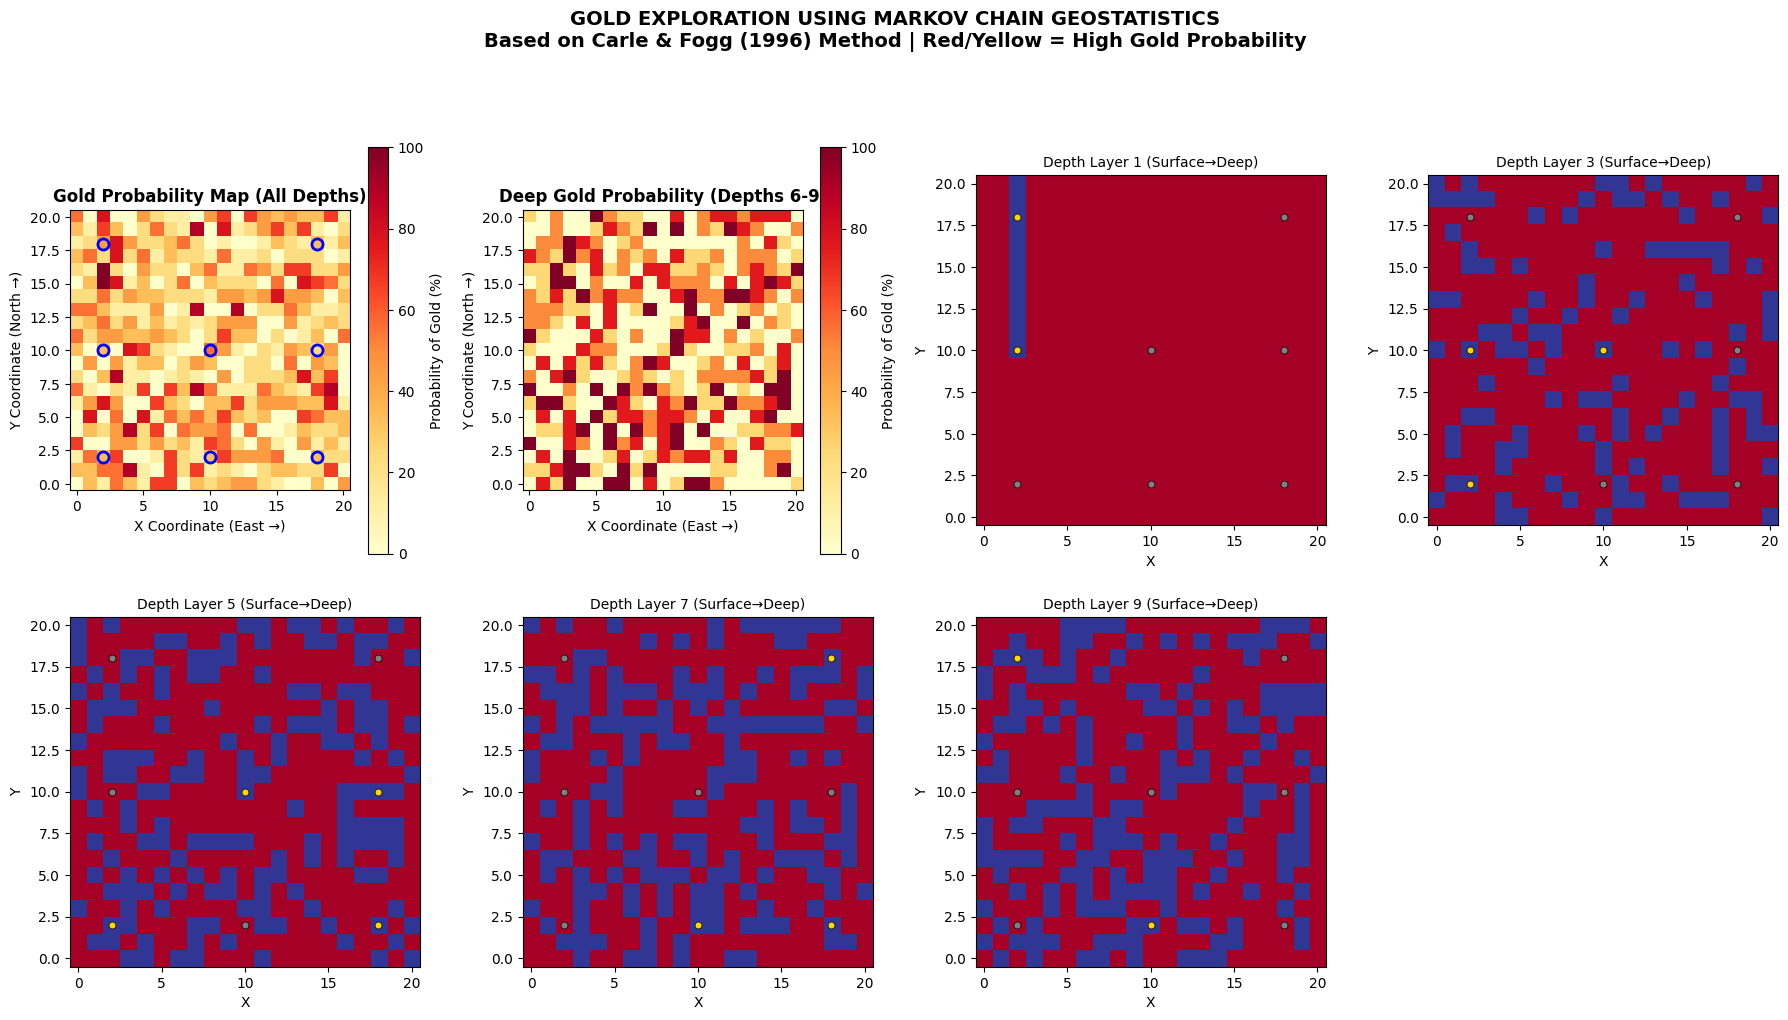

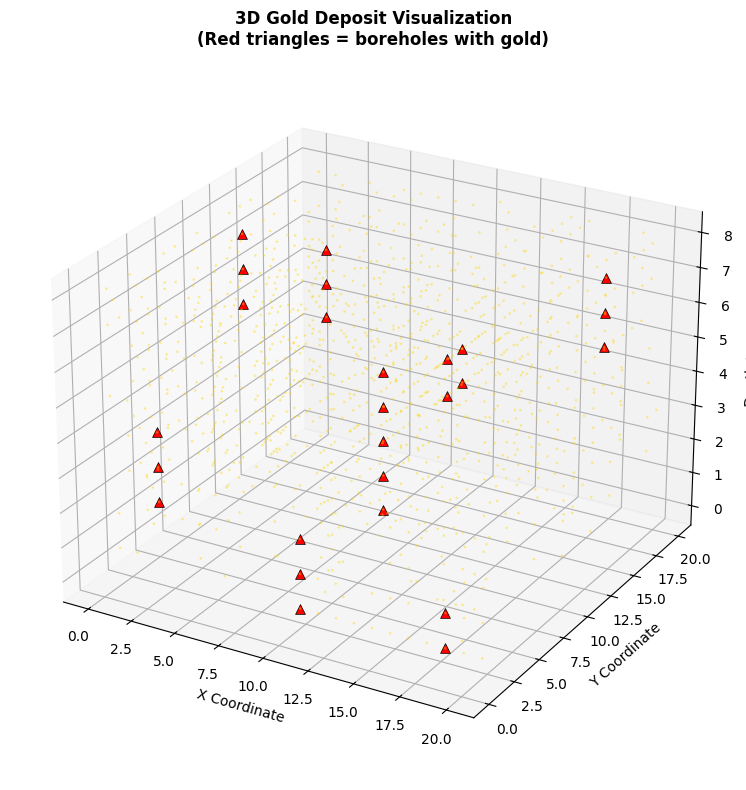

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ========== 1. 问题：寻找黄金位置 ==========
print("="*60)
print("GOLD MINER PROBLEM: Finding Gold Deposits Underground")
print("="*60)
print("Scenario: You are a gold miner exploring an unexplored area.")
print("Data: 8 boreholes with known rock type sequences")
print("Rock types: 0 = Waste Rock (no gold), 1 = Gold-bearing Rock")
print("Objective: Predict where gold is likely to be found")
print("="*60)

# ========== 2. 模拟钻孔数据（代替真实勘探数据）==========
np.random.seed(42)  # 确保结果可重复

# 钻孔位置和岩石序列 (x, y): [depth0, depth1, ..., depth8]
# 1 = 含金岩石, 0 = 废石
boreholes = {
    # 角落钻孔
    (2, 2):   [0, 0, 1, 1, 1, 0, 0, 0, 0],  # 浅层有金
    (2, 18):  [0, 0, 0, 0, 1, 1, 1, 0, 0],  # 中层有金
    (18, 2):  [1, 1, 0, 0, 0, 0, 0, 1, 1],  # 表层和深层有金
    (18, 18): [0, 0, 0, 0, 0, 1, 1, 1, 0],  # 深层有金
    
    # 中心钻孔
    (10, 10): [0, 1, 1, 1, 1, 1, 0, 0, 0],  # 厚金矿层
    
    # 边缘钻孔
    (2, 10):  [0, 0, 0, 0, 0, 0, 1, 1, 1],  # 深层有金
    (10, 2):  [1, 1, 1, 0, 0, 0, 0, 0, 0],  # 表层有金
    (10, 18): [0, 0, 0, 1, 1, 0, 0, 0, 0],  # 中层有金
}

# 网格参数
grid_size = 21  # 21x21 网格（0-20）
depth_levels = 9  # 9个深度层（从地表到地下）

print("\n" + "="*60)
print("EXPLORATION DATA: 8 Boreholes")
print("="*60)
print("Borehole locations and gold-bearing zones:")
for (x, y), seq in boreholes.items():
    gold_depths = [d+1 for d, val in enumerate(seq) if val == 1]
    if gold_depths:
        print(f"  → At ({x:2d}, {y:2d}): Gold found at depths {gold_depths}")
    else:
        print(f"  → At ({x:2d}, {y:2d}): No gold found")

# ========== 3. 方法：计算转移概率矩阵 ==========
def calculate_transition_probabilities(sequences):
    """
    从钻孔序列计算转移概率矩阵
    矩阵含义：P[当前状态][下一个状态] = 概率
    """
    P = np.zeros((2, 2))  # 2x2 矩阵
    counts = np.zeros((2, 2))
    
    for seq in sequences:
        for i in range(len(seq)-1):
            current = seq[i]      # 当前深度岩石类型
            next_rock = seq[i+1]  # 下一个深度岩石类型
            counts[current, next_rock] += 1
    
    # 归一化：每行概率和为1
    for i in range(2):
        if counts[i].sum() > 0:
            P[i] = counts[i] / counts[i].sum()
        else:
            # 如果没有数据，默认50%概率
            P[i] = [0.5, 0.5]
    
    return P

# 收集所有钻孔序列
all_sequences = list(boreholes.values())
P_vertical = calculate_transition_probabilities(all_sequences)

print("\n" + "="*60)
print("STEP 1: Transition Probability Matrix (Vertical Direction)")
print("="*60)
print("Meaning: Probability of rock type change from one depth to next")
print("\n         Next Depth →")
print("         Waste(0)  Gold(1)")
print(f"Current  Waste(0) [{P_vertical[0,0]:.2f}      {P_vertical[0,1]:.2f}]")
print(f"Depth↓   Gold(1)  [{P_vertical[1,0]:.2f}      {P_vertical[1,1]:.2f}]")
print("\nInterpretation:")
print(f"  • If current layer is WASTE → {P_vertical[0,1]*100:.0f}% chance gold below")
print(f"  • If current layer is GOLD  → {P_vertical[1,1]*100:.0f}% chance gold continues")

# ========== 4. 方法：马尔可夫链模拟 ==========
def markov_chain_simulation(P_vertical, boreholes, grid_size, depth_levels):
    """
    使用马尔可夫链模拟整个区域的地下岩石分布
    """
    # 初始化三维网格，-1表示未知
    simulation = -1 * np.ones((grid_size, grid_size, depth_levels), dtype=int)
    
    # 步骤1：放置钻孔数据（硬约束）
    for (x, y), seq in boreholes.items():
        for d in range(len(seq)):
            if x < grid_size and y < grid_size:
                simulation[x, y, d] = seq[d]
    
    # 步骤2：逐点模拟
    for x in range(grid_size):
        for y in range(grid_size):
            # 2.1 模拟地表层（深度0）
            if simulation[x, y, 0] == -1:
                # 使用邻近钻孔的值
                if x > 0 and simulation[x-1, y, 0] != -1:
                    simulation[x, y, 0] = simulation[x-1, y, 0]
                elif y > 0 and simulation[x, y-1, 0] != -1:
                    simulation[x, y, 0] = simulation[x, y-1, 0]
                else:
                    # 没有邻近数据，随机初始化（50%概率）
                    simulation[x, y, 0] = np.random.choice([0, 1])
            
            # 2.2 模拟更深层（马尔可夫链核心）
            for d in range(1, depth_levels):
                if simulation[x, y, d] == -1:
                    current_rock = simulation[x, y, d-1]  # 上一层的岩石类型
                    # 根据转移概率随机决定当前层
                    simulation[x, y, d] = np.random.choice([0, 1], p=P_vertical[current_rock])
    
    return simulation

print("\n" + "="*60)
print("STEP 2: Running Markov Chain Simulation")
print("="*60)
print(f"Grid size: {grid_size} x {grid_size} x {depth_levels} = {grid_size*grid_size*depth_levels} cells")
print("Simulating...")

# 执行模拟
simulation = markov_chain_simulation(P_vertical, boreholes, grid_size, depth_levels)

print("✓ Simulation complete!")

# ========== 5. 结果分析：找金矿 ==========
print("\n" + "="*60)
print("STEP 3: Gold Deposit Analysis")
print("="*60)

# 计算整体统计
total_cells = grid_size * grid_size * depth_levels
gold_cells = np.sum(simulation == 1)
waste_cells = np.sum(simulation == 0)
gold_percentage = gold_cells / total_cells * 100

print(f"Total cells simulated: {total_cells:,}")
print(f"Gold-bearing cells: {gold_cells:,} ({gold_percentage:.1f}%)")
print(f"Waste rock cells: {waste_cells:,} ({100-gold_percentage:.1f}%)")

# 按深度分析金矿分布
print("\nGold distribution by depth:")
for d in range(depth_levels):
    gold_at_depth = np.sum(simulation[:, :, d] == 1)
    percentage = gold_at_depth / (grid_size * grid_size) * 100
    bar = "█" * int(percentage / 2) + "░" * (50 - int(percentage / 2))
    print(f"  Depth {d+1:2d}: {gold_at_depth:3d}/{grid_size*grid_size:3d} cells ({percentage:5.1f}%) {bar}")

# 计算最佳钻探位置
print("\n" + "="*60)
print("GOLD MINER RECOMMENDATIONS")
print("="*60)

# 找出含金概率最高的位置（水平方向）
gold_probability_2d = np.sum(simulation == 1, axis=2) / depth_levels * 100

# 找出前5个最佳位置
flattened = gold_probability_2d.flatten()
top_indices = np.argsort(flattened)[-5:][::-1]

print("\nTop 5 locations with highest gold probability:")
for rank, idx in enumerate(top_indices, 1):
    x = idx // grid_size
    y = idx % grid_size
    prob = flattened[idx]
    print(f"  {rank}. Position ({x:2d}, {y:2d}): {prob:.1f}% chance of finding gold")

# 找出深层黄金富集区（深度5-9）
deep_gold = np.sum(simulation[:, :, 5:9] == 1, axis=2) / 4 * 100
deep_flattened = deep_gold.flatten()
top_deep_indices = np.argsort(deep_flattened)[-5:][::-1]

print("\nTop 5 locations for DEEP gold (depths 6-9):")
for rank, idx in enumerate(top_deep_indices, 1):
    x = idx // grid_size
    y = idx % grid_size
    prob = deep_flattened[idx]
    print(f"  {rank}. Position ({x:2d}, {y:2d}): {prob:.1f}% chance of deep gold")

# ========== 6. 可视化 ==========
print("\n" + "="*60)
print("STEP 4: Generating Visualizations")
print("="*60)

# 创建图形 - 修复：使用 2x4 布局（8个子图）来容纳5个深度切片
fig = plt.figure(figsize=(18, 10))

# 6.1 水平概率图（2D）
ax1 = fig.add_subplot(2, 4, 1)  # 修改为 2x4 的第1个
im1 = ax1.imshow(gold_probability_2d, cmap='YlOrRd', origin='lower', 
                  vmin=0, vmax=100, aspect='equal')
ax1.set_title('Gold Probability Map (All Depths)', fontsize=12, fontweight='bold')
ax1.set_xlabel('X Coordinate (East →)')
ax1.set_ylabel('Y Coordinate (North →)')
plt.colorbar(im1, ax=ax1, label='Probability of Gold (%)')

# 标记钻孔位置
for (x, y), seq in boreholes.items():
    has_gold = any(seq)
    color = 'blue' if has_gold else 'black'
    marker = 'o' if has_gold else 's'
    ax1.plot(y, x, marker, color=color, markersize=8, 
            markerfacecolor='none', markeredgewidth=2)

# 6.2 深层黄金概率图
ax2 = fig.add_subplot(2, 4, 2)  # 修改为 2x4 的第2个
im2 = ax2.imshow(deep_gold, cmap='YlOrRd', origin='lower',
                  vmin=0, vmax=100, aspect='equal')
ax2.set_title('Deep Gold Probability (Depths 6-9)', fontsize=12, fontweight='bold')
ax2.set_xlabel('X Coordinate (East →)')
ax2.set_ylabel('Y Coordinate (North →)')
plt.colorbar(im2, ax=ax2, label='Probability of Gold (%)')

# 6.3 深度切片（显示5个深度层）- 使用 2x4 布局的第3-7个位置
depth_to_plot = [0, 2, 4, 6, 8]
for idx, depth in enumerate(depth_to_plot):
    ax = fig.add_subplot(2, 4, 3 + idx)  # 现在 3+0=3, 3+4=7，都在1-8范围内
    im = ax.imshow(simulation[:, :, depth], cmap='RdYlBu', 
                   vmin=0, vmax=1, origin='lower', aspect='equal')
    ax.set_title(f'Depth Layer {depth+1} (Surface→Deep)', fontsize=10)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    
    # 标记钻孔
    for (x, y), seq in boreholes.items():
        if depth < len(seq):
            color = 'gold' if seq[depth] == 1 else 'gray'
            ax.plot(y, x, 'o', color=color, markersize=5, 
                   markerfacecolor=color, markeredgecolor='black', 
                   markeredgewidth=0.5)

plt.suptitle('GOLD EXPLORATION USING MARKOV CHAIN GEOSTATISTICS\n' +
             'Based on Carle & Fogg (1996) Method | Red/Yellow = High Gold Probability',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # 修复：为标题留出空间
plt.show()

# 6.4 3D 可视化（可选）
fig_3d = plt.figure(figsize=(12, 8))
ax_3d = fig_3d.add_subplot(111, projection='3d')

# 创建金矿位置的3D散点图
gold_positions = np.where(simulation == 1)
if len(gold_positions[0]) > 0:
    # 采样以加快渲染（如果点太多）
    sample_size = min(5000, len(gold_positions[0]))
    indices = np.random.choice(len(gold_positions[0]), sample_size, replace=False)
    
    xs = gold_positions[0][indices]
    ys = gold_positions[1][indices]
    zs = gold_positions[2][indices]
    
    ax_3d.scatter(xs, ys, zs, c='gold', marker='o', alpha=0.3, s=1)
    
    # 标记钻孔位置
    for (x, y), seq in boreholes.items():
        for d, rock in enumerate(seq):
            if rock == 1:
                ax_3d.scatter([x], [y], [d], c='red', marker='^', s=50, 
                             edgecolors='black', linewidth=0.5)

ax_3d.set_xlabel('X Coordinate')
ax_3d.set_ylabel('Y Coordinate')
ax_3d.set_zlabel('Depth Level')
ax_3d.set_title('3D Gold Deposit Visualization\n(Red triangles = boreholes with gold)',
                fontsize=12, fontweight='bold')
ax_3d.view_init(elev=25, azim=-60)

plt.tight_layout()
plt.show()
